# Executive Summary

## Decisions to be impacted
The goal of this project is to predict and highlight crime hotspots to assist law enforcement in better resource allocation and proactive crime prevention. Accurate crime prediction allows for optimized patrol routing, quicker response to high-risk areas, and informed decision-making in crime prevention initiatives.

## Business Value
By predicting hotspots, this project provides value to both law enforcement and the community. Benefits include:

- Reduced crime rates through proactive policing
- Increased efficiency for allocation of public funds
- Enhanced public safety and confidence


## Data Assets

- NIBRS data: Crime incidents with spatial-temporal information from 2021 to January 2025
- Supplementary datasets: Neighborhood population census data and city/neighborhood boundary shapefiles


# Data Pre-Processing

In [1]:
# put the file in ur google drive to use
# from google.colab import drive
# drive.mount('/content/drive/')
data_path = '../data/cleaned_2021-jan2025.csv'
city_bounds_path ='../data/city_bounds/stl_boundary.shp'

In [2]:
# !wget 'https://www.stlouis-mo.gov/data/upload/data-files/stl_boundary.zip'
# !unzip '/content/stl_boundary.zip'
# !rm "/content/stl_boundary.zip"
# city_bounds_path ='/content/stl_boundary.shp'

In [3]:
# !wget 'https://static.stlouis-mo.gov/open-data/planning/neighborhoods/neighborhoods.zip'
# !unzip '/content/neighborhoods.zip'
# !rm "/content/neighborhoods.zip"
neighborhoods_path = '/content/Neighborhoods/Neighborhoods.shp'

Dependencies

In [4]:
# !pip install esda

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point
from esda.moran import Moran_Local
from libpysal.weights import Queen
from pyproj import Transformer
import esda
import libpysal
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pickle
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

Category Function & Constants

In [6]:

NIBRS_CATEGORIES = {
    'ASSAULT': ['13A', '13B', '13C'],
    'THEFT': ['23A', '23B', '23C', '23D', '23E', '23F', '23G', '23H'],
    'SEX CRIMES': ['36A', '36B', '11A', '11B', '11C', '11D'],
    'HOMICIDE': ['09A', '09B', '09C'],
    'GROUP B': ['90A', '90F','90B','90C','90D','90E','90H','90H','90I','90J','90Z'],
    'FRAUD': ['26A', '26B', '26C', '26D', '26E'],
    'DRUG OFFENSES': ['35A', '35B'],
    'BURGLARY': ['220']
}

    # Function to map NIBRS code to category
def map_to_category(nibrs_code):
    """
    Map NIBRS code to simplified crime types.
    """
    # Convert to string and strip whitespace for consistent comparison
    nibrs_code = str(nibrs_code).strip()

    if nibrs_code in NIBRS_CATEGORIES['ASSAULT'] or nibrs_code in NIBRS_CATEGORIES['HOMICIDE']:
        return "VIOLENT CRIME"
    elif nibrs_code in NIBRS_CATEGORIES['SEX CRIMES']:
        return "SEX CRIMES"
    elif nibrs_code in NIBRS_CATEGORIES['THEFT']:
        return "THEFT"
    else:
        return 'OTHER'

Preprocessing function definition

In [7]:
def preprocess_crime_data(file_path, city_bounds_path):
    """
    Preprocess crime data for spatial-temporal point process modeling.
    Only drops rows where lat, lon, or time is null.
    Preserves the original incident date in the final dataframe.

    Parameters:
    file_path (str): Path to the CSV file containing crime data

    Returns:
    pandas.DataFrame: Processed dataframe with normalized features
    """
    print(f"Loading data from {file_path}...")

    # Load data
    df = pd.read_csv(file_path)

    print(f"Original data shape: {df.shape}")

    # Make a copy to avoid modifying the original
    processed_df = df.copy()

    # 1. Remove points outside city bounds
    print("\nRemoving points outside city bounds...")
    city_bounds = gpd.read_file(city_bounds_path)
    points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
    points.set_crs(epsg=4326, inplace=True)

    if city_bounds.crs != points.crs:
        points = points.to_crs(city_bounds.crs)

    within_points = gpd.sjoin(points, city_bounds, how='inner', predicate = 'within')
    columns_to_drop = ['index_right'] + list(city_bounds.columns)
    within_points = within_points.drop(columns=columns_to_drop)
    processed_df = within_points
    print("\nRemoved ", len(points) - len(within_points), " points outside city bounds.")

    # 2. Time normalization
    print("\nNormalizing time data...")

    # Extract hours, minutes, seconds and convert to fraction of day
    def time_to_fraction(time_str):
        try:
            if pd.isna(time_str):
                return np.nan

            # Handle various time formats
            if ':' in str(time_str):
                parts = str(time_str).split(':')
                if len(parts) == 3:  # HH:MM:SS
                    hours, minutes, seconds = map(int, parts)
                elif len(parts) == 2:  # HH:MM
                    hours, minutes = map(int, parts)
                    seconds = 0
                else:
                    return np.nan
            else:
                # Handle military time format
                try:
                    time_int = int(time_str)
                    hours = time_int // 100
                    minutes = time_int % 100
                    seconds = 0
                except:
                    return np.nan

            return (hours * 3600 + minutes * 60 + seconds) / (24 * 3600)
        except:
            return np.nan

    processed_df['time_fraction'] = processed_df['OccurredFromTime'].apply(time_to_fraction)
    processed_df['IncidentDate'] = pd.to_datetime(processed_df['IncidentDate'], format = "mixed")

    # 3. Spatial normalization - Only drop if lat, lon, OR time is missing (essential for analysis)
    print("\nNormalizing spatial coordinates...")

    # Identify rows with any missing spatial or time data or early date or bad adress
    address_filter = ['200 S TUCKER BLVD', '1915 OLIVE ST', '1915 OLIVE']
    missing_data_mask = (
    (processed_df['Longitude'].isna()) |
    (processed_df['time_fraction'].isna()) |
    (processed_df['IncidentDate'] < '2021-01-01') |
    (processed_df['IncidentLocation'].isin(address_filter))
)

    # Count missing values before dropping
    print(f"Rows with missing latitude: {processed_df['Latitude'].isna().sum()}")
    print(f"Rows with missing longitude: {processed_df['Longitude'].isna().sum()}")
    print(f"Rows with missing time: {processed_df['time_fraction'].isna().sum()}")
    print(f"Rows with missing date: {np.sum(processed_df['IncidentDate'] < '2021-01-01')}")
    print(f"Rows with SLMPD or DoC address: {np.sum(processed_df['IncidentLocation'].isin(address_filter))}")
    print(f"Total rows to be removed due to missing essential data: {missing_data_mask.sum()}")


    print(f"Total rows to be removed due to early date: {np.sum(processed_df['IncidentDate'] >= '2021-01-01')}")

    # Drop rows with missing essential data
    processed_df = processed_df[~missing_data_mask]
    print(f"Data shape after dropping rows with missing essential data: {processed_df.shape}")

    # Normalize time to have SD=1
    mean_time = processed_df['time_fraction'].mean()
    std_time = processed_df['time_fraction'].std()
    processed_df['time_normalized'] = (processed_df['time_fraction'] - mean_time) / std_time

    # Normalize coordinates to [0,1] range and then standardize
    lat_min = processed_df['Latitude'].min()
    lat_max = processed_df['Latitude'].max()
    processed_df['lat_01'] = (processed_df['Latitude'] - lat_min) / (lat_max - lat_min)

    lon_min = processed_df['Longitude'].min()
    lon_max = processed_df['Longitude'].max()
    processed_df['lon_01'] = (processed_df['Longitude'] - lon_min) / (lon_max - lon_min)

    # Then standardize to have SD=1
    lat_mean = processed_df['lat_01'].mean()
    lat_std = processed_df['lat_01'].std()
    processed_df['lat_normalized'] = (processed_df['lat_01'] - lat_mean) / lat_std

    lon_mean = processed_df['lon_01'].mean()
    lon_std = processed_df['lon_01'].std()
    processed_df['lon_normalized'] = (processed_df['lon_01'] - lon_mean) / lon_std

    # 4. Crime type categorization
    print("\nCategorizing crime types...")
    processed_df['crime_category'] = processed_df['NIBRS'].apply(map_to_category)

    # Display distribution before filtering
    print("\nCrime category distribution before filtering:")
    print(processed_df['crime_category'].value_counts())

    # Create final dataframe with relevant columns - preserving the original IncidentDate
    final_cols = ['IncidentDate', 'time_normalized', 'lat_normalized', 'lon_normalized',
                  'crime_category', 'NIBRS', 'Latitude', 'Longitude', 'IncidentNum',
                  'FirearmUsed', 'Offense', 'IncidentLocation']

    final_df = processed_df[final_cols]

    # Print summary statistics
    print(f"\nFinal processed data shape: {final_df.shape}")
    print("\nCrime category distribution in final dataset:")
    print(final_df['crime_category'].value_counts())


    return final_df

In [8]:
processed_data = preprocess_crime_data(data_path, city_bounds_path)
processed_data.head()

Loading data from ../data/cleaned_2021-jan2025.csv...


C:\Users\jz043x\AppData\Local\Temp\ipykernel_14288\3904164651.py:16: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Original data shape: (228776, 22)

Removing points outside city bounds...

Removed  4845  points outside city bounds.

Normalizing time data...

Normalizing spatial coordinates...
Rows with missing latitude: 0
Rows with missing longitude: 0
Rows with missing time: 0
Rows with missing date: 939
Rows with SLMPD or DoC address: 626
Total rows to be removed due to missing essential data: 1561
Total rows to be removed due to early date: 222992
Data shape after dropping rows with missing essential data: (222370, 23)

Categorizing crime types...


C:\Users\jz043x\AppData\Local\Temp\ipykernel_14288\3904164651.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df['time_normalized'] = (processed_df['time_fraction'] - mean_time) / std_time
C:\Users\jz043x\AppData\Local\Temp\ipykernel_14288\3904164651.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df['lat_01'] = (processed_df['Latitude'] - lat_min) / (lat_max - lat_min)
C:\Users\jz043x\AppData\Local\Temp\ipykernel_14288\3904164651.py:113: SettingWithCopyWarning: 
A value is t


Crime category distribution before filtering:
crime_category
OTHER            149040
THEFT             47075
VIOLENT CRIME     25178
SEX CRIMES         1077
Name: count, dtype: int64

Final processed data shape: (222370, 12)

Crime category distribution in final dataset:
crime_category
OTHER            149040
THEFT             47075
VIOLENT CRIME     25178
SEX CRIMES         1077
Name: count, dtype: int64


C:\Users\jz043x\AppData\Local\Temp\ipykernel_14288\3904164651.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_df['crime_category'] = processed_df['NIBRS'].apply(map_to_category)


,IncidentDate,time_normalized,lat_normalized,lon_normalized,crime_category,NIBRS,Latitude,Longitude,IncidentNum,FirearmUsed,Offense,IncidentLocation
2,2021-04-11,0.999405,0.010247,-0.148417,OTHER,90D,38.629010,-90.246376,2114653,No,DRIVING WHILE INTOXICATED,888-898 S VANDEVENTER AVE
3,2022-07-10,-1.498785,1.476760,-1.080116,OTHER,90Z,38.688334,-90.274738,2230247,No,LEAVING THE SCENE OF A MOTOR VEHICLE ACCIDENT,6000 NATURAL BRIDGE AVE
4,2023-10-24,0.367678,-1.088303,-0.692877,OTHER,90Z,38.584571,-90.262950,2304880,No,LEAVING SCENE OF ACCIDENT,4200 ELLENWOOD AVE
29,2023-08-28,-1.905579,0.123095,1.021151,OTHER,240,38.633575,-90.210773,19028410,No,STEALING - MOTOR VEHICLE/WATERCRAFT/AIRCRAFT &...,22ND STREET
32,2021-10-26,-0.421979,-0.850444,-1.679207,OTHER,26A,38.594193,-90.292975,19035349,No,STEALING,LINDENWOOD


## Outlier Detection & Exploration

### Lat/Long Binning and Top Points

In [9]:
def gen_heatmap(df, bin_size=0.001, data_range="Total"):
    # Define the grid size (e.g., 0.01 degrees for a medium-sized city)
    lat_min, lat_max = df['Latitude'].min(), df['Latitude'].max()
    lon_min, lon_max = df['Longitude'].min(), df['Longitude'].max()
    lat_bins = np.arange(lat_min, lat_max, bin_size)
    lon_bins = np.arange(lon_min, lon_max, bin_size)

    heatmap, lat_edges, lon_edges = np.histogram2d(df['Latitude'], df['Longitude'], bins=[lat_bins, lon_bins])

    plot_heatmap(heatmap, f"{data_range} Data Crime Heatmap {bin_size} Lat/long")

    return heatmap, lat_edges, lon_edges

def explore_top_heatmap_points(df, heatmap, lat_edges, lon_edges):
  top_10_indices = np.unravel_index(np.argsort(heatmap.flatten())[-10:][::-1], heatmap.shape)

  # Iterate through the top 10 indices and print the results
  for lat_index, lon_index in zip(*top_10_indices):
      # Determine the latitude and longitude range of the current bin
      lat_range = (lat_edges[lat_index], lat_edges[lat_index + 1])
      lon_range = (lon_edges[lon_index], lon_edges[lon_index + 1])

      # Print the results for the current bin
      print(f'Bin value: {heatmap[lat_index, lon_index]}')
      print(f'Latitude range: {lat_range}')
      print(f'Longitude range: {lon_range}')
      print('-' * 20)

      points_within_bounds = df[
          (df['Latitude'] >= lat_range[0]) & (df['Latitude'] < lat_range[1]) &
          (df['Longitude'] >= lon_range[0]) & (df['Longitude'] < lon_range[1])
      ]

      # Display the points within the bounds
      print(points_within_bounds.head(5)[['Offense', 'IncidentLocation']])

# Model Updates

## CNN-LSTM

# Source Code

[GitHub Link](https://github.com/jakebeinart/crime-dashboard)

**Note**: Some of the code may be contained in separate branches and not merged into the repository yet.


# Next Steps


*   Use lat/long bins as inputs for CNN-LSTM model
*   Use a Hawkes process to attempt to model self-exciting nature of crime in space and time
  * Hawkes process model will go like: $\lambda(t,x,y,c) = \alpha f_{x,y}(x,y|c)S(t,c) + H(t,x,y,c)$, where $\lambda(c,t,x,y)$ is the intensity of crime category c at space-time location $x,y,t$.  $\alpha$ is a normalizing constant $f_{x,y}(x,y|c)$ is a KDE , $S(t,c)$ is a sarima model, and $H(t,x,y,c)$ is the Hawkes process kernel. Overall this constitutes a hawkes process model with background intensity $\alpha f_{x,y}(x,y|c)S(t,c)$, and self - exciting kernel $H(t,x,y,c)$
*   Integrate the models into the existing web app to make them interactive and cool



In [10]:
# Define the grid size
bin_size = 0.003

lat_min, lat_max = processed_data['Latitude'].min(), processed_data['Latitude'].max()
lon_min, lon_max = processed_data['Longitude'].min(), processed_data['Longitude'].max()
lat_bins = np.arange(lat_min, lat_max, bin_size)
lon_bins = np.arange(lon_min, lon_max, bin_size)


# Generate the unique dates
unique_dates = processed_data['IncidentDate'].unique()

# Function to generate an image for a specific date
def generate_image_for_date(date, bin_size):
    date_data = processed_data[processed_data['IncidentDate'] == date]
    lat_bins = np.arange(lat_min, lat_max, bin_size)
    long_bins = np.arange(lon_min, lon_max, bin_size)
    
    image = np.histogram2d(date_data['Latitude'], date_data['Longitude'], bins=[lat_bins, long_bins])[0]
    return image

# Generate images for all unique dates
images = {date: generate_image_for_date(date, bin_size) for date in unique_dates}

In [11]:
from sklearn.model_selection import train_test_split

# Convert dates to numerical format
date_to_num = {date: i for i, date in enumerate(unique_dates)}

X = np.array([date_to_num[date] for date in unique_dates])
y = np.array([images[date] for date in unique_dates])

# Reshape X to have a shape suitable for the LSTM
X = X.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, LSTM, Reshape, Concatenate, BatchNormalization, Dropout

def sparse_loss(y_true, y_pred):
    mse_loss = tf.keras.losses.mean_squared_error(y_true, y_pred)
    l1_loss = tf.reduce_sum(tf.abs(y_pred))
    return mse_loss + 0.01 * l1_loss


def sparse_rewarded_loss(y_true, y_pred):
    # MSE loss
    mse_loss = tf.keras.losses.mean_squared_error(y_true, y_pred)

    # L1 loss for sparsity
    l1_loss = tf.reduce_sum(tf.abs(y_pred))
    
    # True positive reward: heavily reward correct non-zero predictions
    true_positive_mask = tf.cast(tf.greater(y_true, 0), tf.float32)
    true_positive_reward = tf.reduce_sum(true_positive_mask * y_pred)

    # Combine the losses and rewards
    total_loss = mse_loss + 0.01 * l1_loss - 0.1 * true_positive_reward  
    return total_loss

# Define the model
def create_cnn_lstm_model(input_shape):
    input_date = Input(shape=(1,))
    reshaped_date = Reshape((1, 1))(input_date)
    
    # CNN Model
    cnn_input = Input(shape=input_shape)
    x = Reshape((*input_shape, 1))(cnn_input)  # Add channel dimension
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)
    cnn_output = Dense(128, activation='relu')(x)
    cnn_output = Dropout(0.5)(cnn_output)
    cnn_output = Reshape((1, 128))(cnn_output)
    
    # LSTM Model
    lstm_input = Concatenate()([reshaped_date, cnn_output])
    lstm_output = LSTM(64, return_sequences=True)(lstm_input)
    lstm_output = LSTM(64)(lstm_output)
    
    # Output layer
    output = Dense(np.prod(input_shape), activation='sigmoid')(lstm_output)
    output = Reshape(input_shape)(output)
    
    model = Model(inputs=[input_date, cnn_input], outputs=output)
    return model

# Create the model
input_shape = (78, 47)  # Shape of each image
model = create_cnn_lstm_model(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit([X_train, y_train], y_train, epochs=20, batch_size=32, validation_split=0.1)





Epoch 1/20

38/38 [==============================] - 10s 89ms/step - loss: 0.2598 - val_loss: 0.1812
Epoch 2/20
38/38 [==============================] - 2s 47ms/step - loss: 0.1091 - val_loss: 0.0849
Epoch 3/20
38/38 [==============================] - 2s 55ms/step - loss: 0.0821 - val_loss: 0.0822
Epoch 4/20
38/38 [==============================] - 2s 53ms/step - loss: 0.0810 - val_loss: 0.0817
Epoch 5/20
38/38 [==============================] - 2s 50ms/step - loss: 0.0808 - val_loss: 0.0814
Epoch 6/20
38/38 [==============================] - 1s 32ms/step - loss: 0.0806 - val_loss: 0.0813
Epoch 7/20
38/38 [==============================] - 1s 31ms/step - loss: 0.0805 - val_loss: 0.0813
Epoch 8/20
38/38 [==============================] - 1s 33ms/step - loss: 0.0805 - val_loss: 0.0812
Epoch 9/20
38/38 [==============================] - 1s 36ms/step - loss: 0.0804 - val_loss: 0.0812
Epoch 10/20
38/38 [==============================] - 1s 32ms/step - loss: 0.0804 - val_loss: 0.0812
Epo

5/5 [==============================] - 0s 9ms/step - loss: 0.0795
Test Loss: 0.07948746532201767
1/1 [==============================] - 1s 1s/step


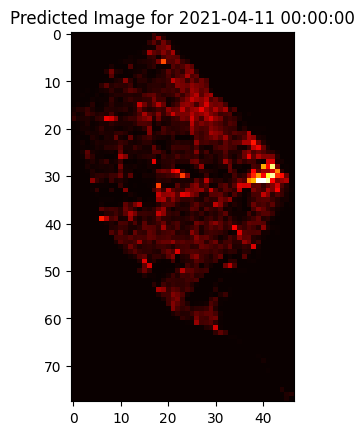

In [13]:
# Evaluate the model
loss = model.evaluate([X_test, y_test], y_test)
print(f'Test Loss: {loss}')

# Predict an image for a given date
date_to_predict = unique_dates[0]
date_num = date_to_num[date_to_predict]
prediction = model.predict([np.array([[date_num]]), np.zeros_like(y_train[0:1])])
predicted_image = prediction.reshape(input_shape)

# Visualize the predicted image
import matplotlib.pyplot as plt

plt.imshow(predicted_image, cmap='hot', interpolation='nearest')
plt.title(f'Predicted Image for {date_to_predict}')
plt.show()

1/1 [==============================] - 0s 31ms/step


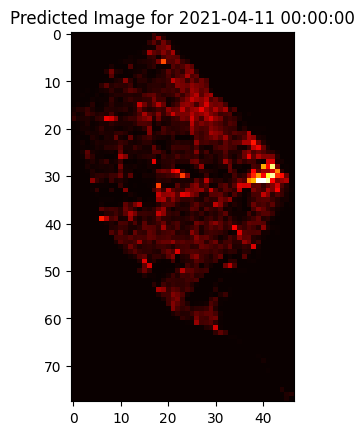

1/1 [==============================] - 0s 31ms/step


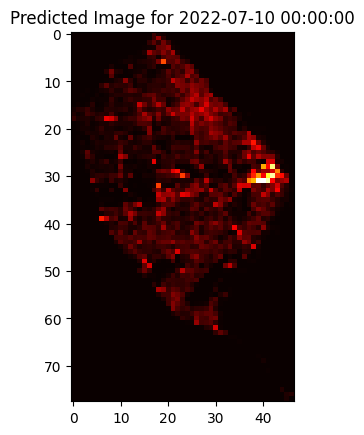

1/1 [==============================] - 0s 31ms/step


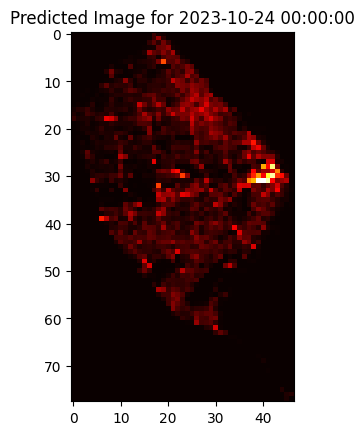

1/1 [==============================] - 0s 16ms/step


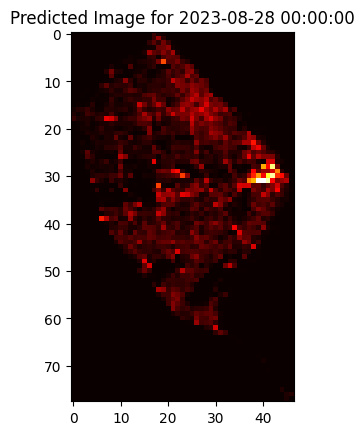

1/1 [==============================] - 0s 47ms/step


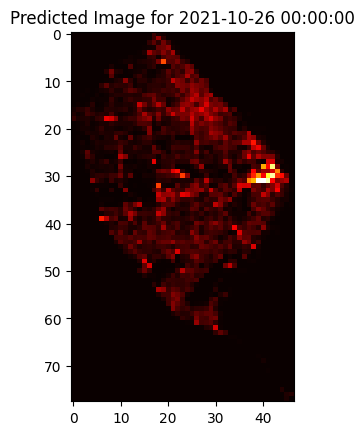

In [14]:
# Predict an image for a given date
for date_to_predict in unique_dates[:5]:
    date_num = date_to_num[date_to_predict]
    prediction = model.predict([np.array([[date_num]]), np.zeros_like(y_train[0:1])])
    predicted_image = prediction.reshape(input_shape)
    
    # Visualize the predicted image
    import matplotlib.pyplot as plt
    
    plt.imshow(predicted_image, cmap='hot', interpolation='nearest')
    plt.title(f'Predicted Image for {date_to_predict}')
    plt.show()

6.0


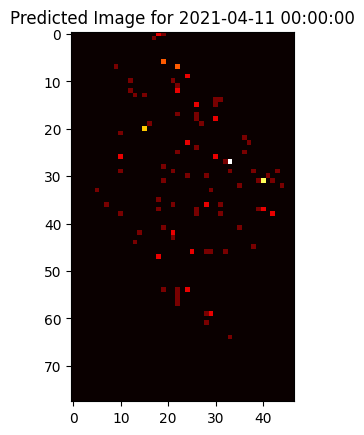

6.0


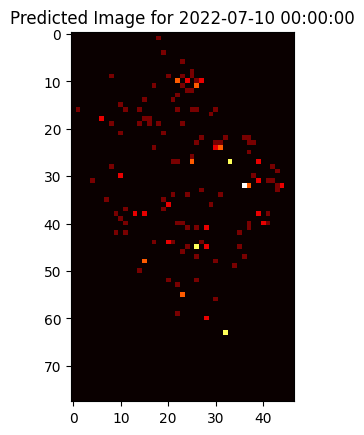

13.0


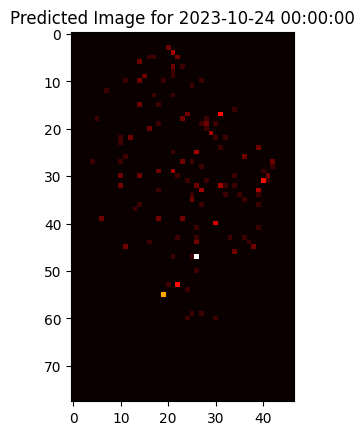

5.0


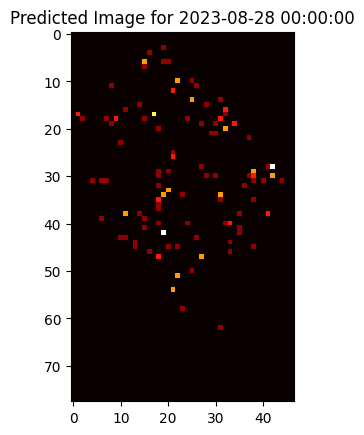

9.0


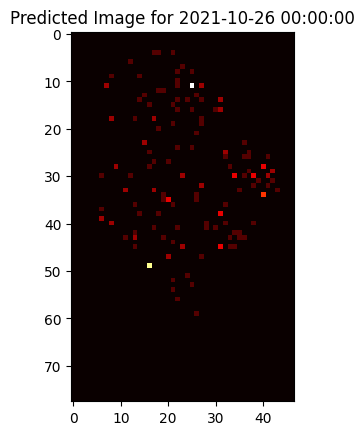

In [18]:
# print(images.keys())

for image in list(images.keys())[:5]:
    print(images[image].max())
    
    plt.imshow(images[image], cmap='hot', interpolation='nearest')
    plt.title(f'Predicted Image for {image}')
    plt.show()

In [16]:
list(images.values())[0].max()

6.0

In [17]:
predicted_image.max()

0.9935859